<a href="https://colab.research.google.com/github/CesarB2025/FICO-challenge/blob/main/08_Advanced_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#FICO Analytic Challenge Week 8
##© Fair Isaac 2024

#Advanced Feature Generation
Feature generation in neural networks for fraud detection involves creating sophisticated features to better identify fraudulent activities. By transforming raw data into meaningful inputs, we improve the model's ability to detect subtle patterns of fraud, enhancing its predictive accuracy and robustness.

Purpose of Feature Generation:
- Enhance detection by highlighting behaviors associated with fraud.
- Improve accuracy by providing the best possible data representations.

Types of Features for Fraud Detection:
- Temporal Features: Capture transaction timing and frequency to spot unusual patterns.
- Relational Features: Analyze relationships between transaction entities to uncover discrepancies.

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Upload pre-processed data
df1 = pd.read_csv('/content/drive/MyDrive/FICO Analytic Challenge/Data/train_features.csv')
df2 = pd.read_csv('/content/drive/MyDrive/FICO Analytic Challenge/Data/test_B_features.csv')
df = pd.concat([df1, df2])

df = df.reset_index(drop=True)
df['datetime'] =  pd.to_datetime(df['transactionDateTime'])
df = df.sort_values(by=['pan','datetime'])
df = df.reset_index(drop=True)

In [4]:
# Look at the column names
df.columns

Index(['pan', 'merchant', 'category', 'transactionAmount', 'first', 'last',
       'mdlIsFraudTrx', 'mdlIsFraudAcct', 'is_train', 'cardholderCountry',
       'cardholderState', 'transactionDateTime', 'gender', 'street', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'merchCountry', 'merchState', 'deltaTime',
       'amt_trend_24h', 'amt_trend_5e', 'RelativeAmount', 'count_trend_1h',
       'num_last_24_hours', 'amount_diff', 'user_avg_amount', 'category_ratio',
       'IS_0_TO_5AM', 'is_off_hours', 'IsHighValue', 'repeat_amt',
       'num_hi_amt_last_hour', 'is_cnp', 'transactionHour', 'is_international',
       'is_late_night', 'datetime'],
      dtype='object')

# Advanced Feature Generation for Credit Card Fraud Detection

Though we have already covered somewhat advanced features in week 4, there is still information to be squeezed from the data. We will investigate 3 key concepts in this notebook:
* ratio variables
* exponential weighting
* repeat events



## Ratio Variables

Ratio variables are perfect for detecting anomalies in spending patterns over time. The problem with simple "last hour" or "last day" variables is that you have no knowledge about this customer's habits outside of that specified timeframe. It's possible that the user naturally fluctuates rapidly throughout the day or week, but we're lacking the necessary long-period information. Typically you want the numerator to be something which encapsulates a time over which periodic behaviors can undergo a full cycle. For example: a user's spending habits might correlate with their pay cycle (2 weeks), or paying off their bills such as a car payment or rent (1 month). We don't want these non-fraud behaviors to trigger any alarm in our variables, so we make the numerator long enough for it to average out. On the other hand, we want our denominator to capture several of these cycles to ensure the numerator truly is reflective of that user's spending patterns. Please create at least three ratio variables which capture transaction frequency or spending amount averages. You may want to use rolling windows for these.


In [5]:
# Example: rolling mean of last 14 days (2 weeks) vs. rolling mean of last 60 days (2 months)
df.set_index('datetime', inplace=True)  # Set the date column as the index
df['rolling_mean_14D'] = df.groupby('pan')['transactionAmount'].rolling(window='14D', min_periods=1).mean().reset_index(level=0, drop=True)
df['rolling_mean_60D'] = df.groupby('pan')['transactionAmount'].rolling(window='60D', min_periods=1).mean().reset_index(level=0, drop=True)
df['ratio_14D_to_60D'] = df['rolling_mean_14D'] / df['rolling_mean_60D']
df.reset_index(inplace=True)

If you want to alter the range of the window, simply change the window parameter in the rolling function. Here, we've specified '14D' and '60D' respectively. If you want to make a variable which goes over a window of a month, for instance, you could replace the parameter with '30D'

In [6]:
# Making sure that NaN values are replaced with zeros because they can cause issues with our rolling average calculations
df = df.fillna(0)
df.reset_index(inplace=True)

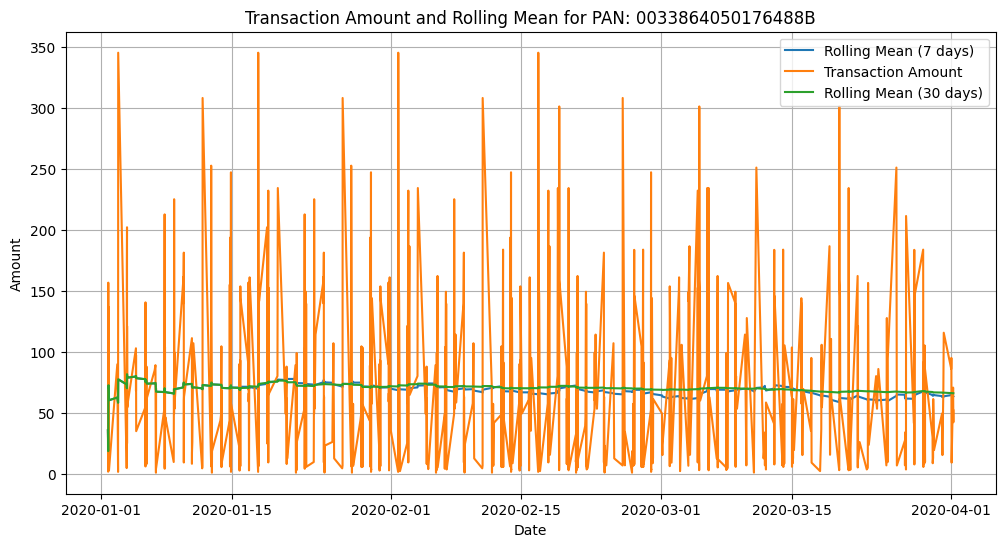

In [7]:
# Visualizing ratio variables that we have calulated
pan_number = df['pan'].unique()[0]  # Select the first pan number for example
subset = df[df['pan'] == pan_number]

# Choose a time range (e.g., first 3 months)
start_date = subset['datetime'].min()
end_date = start_date + pd.DateOffset(months=3)
subset = subset[(subset['datetime'] >= start_date) & (subset['datetime'] <= end_date)]

plt.figure(figsize=(12, 6))
plt.plot(subset['datetime'], subset['rolling_mean_14D'], label='Rolling Mean (7 days)')
plt.plot(subset['datetime'], subset['transactionAmount'], label='Transaction Amount')
plt.plot(subset['datetime'], subset['rolling_mean_60D'], label='Rolling Mean (30 days)')

plt.title(f'Transaction Amount and Rolling Mean for PAN: {pan_number}')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)
plt.show()

Now, let's visualize the ratio of the 14-day rolling average and 60 day rolling average. Calculating this ratio can highlight periods where the short-term trend is significantly different from the long-term trend, indicating potential anomalies, seasonal effects, or sudden changes in behavior.

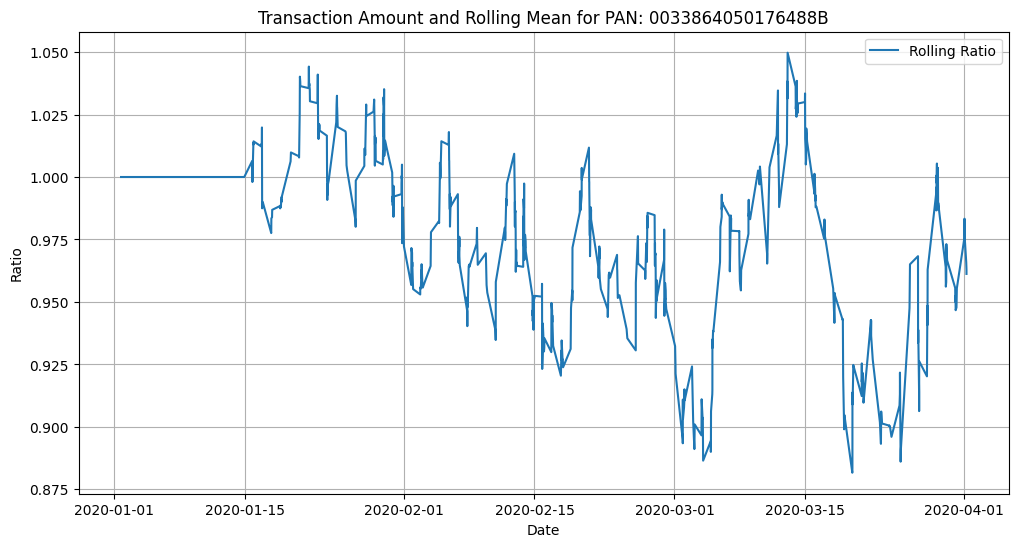

In [8]:
# Plotting ratio of 14-day rolling average to 60-day rolling average
pan_number = df['pan'].unique()[0]  # Select the first pan number for example
subset = df[df['pan'] == pan_number]

# Choose a time range (e.g., first 3 months)
start_date = subset['datetime'].min()
end_date = start_date + pd.DateOffset(months=3)
subset = subset[(subset['datetime'] >= start_date) & (subset['datetime'] <= end_date)]

plt.figure(figsize=(12, 6))
plt.plot(subset['datetime'], subset['ratio_14D_to_60D'], label='Rolling Ratio')

plt.title(f'Transaction Amount and Rolling Mean for PAN: {pan_number}')
plt.xlabel('Date')
plt.ylabel('Ratio')
plt.legend()
plt.grid(True)
plt.show()

## Exponential Weighting

We have some notion of how to leverage long-term spending patterns to detect fraud, but what if we wanted to detect the instantaneous frauds as they're occurring? Exponential event and time decay are designed specifically for this task. By giving priority to the most recent transaction, we are able to detect fraud even sometimes on the very first fraud attempt, saving banks even more money.


### Below is an example of the exponential weighted mean function over time

In [9]:
df['datetime'] =  pd.to_datetime(df['transactionDateTime'])
df.reset_index(drop=True,inplace=True)
# Define halflife in Days
halflife = 1.  #Day

df['ewm_1D'] = df.groupby('pan').apply(
    lambda group: group['transactionAmount'].ewm(halflife=halflife, adjust=False).mean()
).reset_index(level=0, drop=True)
# Making sure that NaN values are replaced with zeros because they can cause
# issues with our rolling average calculations
df = df.fillna(0)


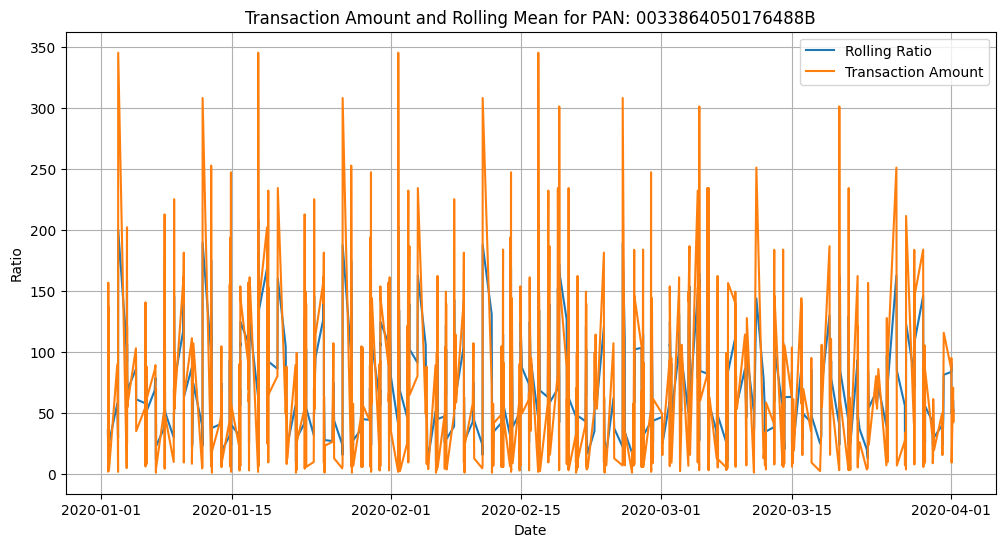

In [10]:
# Plotting ratio of 14-day rolling average to 60-day rolling average
pan_number = df['pan'].unique()[0]  # Select the first pan number for example
subset = df[df['pan'] == pan_number]

# Choose a time range (e.g., first 3 months)
start_date = subset['datetime'].min()
end_date = start_date + pd.DateOffset(months=3)
subset = subset[(subset['datetime'] >= start_date) & (subset['datetime'] <= end_date)]

plt.figure(figsize=(12, 6))
plt.plot(subset['datetime'], subset['ewm_1D'], label='Rolling Ratio')
plt.plot(subset['datetime'], subset['transactionAmount'], label='Transaction Amount')

plt.title(f'Transaction Amount and Rolling Mean for PAN: {pan_number}')
plt.xlabel('Date')
plt.ylabel('Ratio')
plt.legend()
plt.grid(True)
plt.show()

Here, halflife (the time it takes for the value to decay to half) is a parameter which dictates how much you would like to prioritize more recent events. The larger halflife is, the less you prioritize recent events, and the smaller halflife is, the more you emphasize recent events.

# Different profile filters distinguish different basic profile variable types
Examples:
- Time Averages
- Repeats

# Time Averages
- Weighted average rate of change over time
- Weighting function gives
    - Unit weight to current time
    - Exponential suppression for earlier events, e.g. e^[(𝑡_(𝑛−1)−𝑡_𝑛)/𝑇]

# Repeats
- Counts how many repeat events have a specified property
- Normal repeat counting goes as 1, 2, 3, 4, ….
- Falcon uses exponentially decayed repeat counting
- If current event qualifies as repeats, then multiply prior count by e^(−dt/T) before adding 1
- If current event does not qualify as repeat, then reset variable to 0


In [11]:
def compute_timedecay_rate(df, decay=3600, name = "time_decay"):
    avg_amount_list = []
    current_count_rate = 0
    current_amount_rate = 0
    current_pan = None

    for index, row in df.iterrows():
        DC = np.exp(-row["deltaTime"]/decay)
        if (row["pan"] != current_pan):
            current_pan = row["pan"]
            current_count_rate = 0
            current_amount_rate = 0
            DC = 0
        current_count_rate = 1 + current_count_rate*DC
        current_amount_rate = row["transactionAmount"] + current_amount_rate*DC
        avg_amount = current_amount_rate / current_count_rate
        avg_amount_list.append(avg_amount)
    df[name] = avg_amount_list


In [12]:
def compute_hi_repeat(df, decay=60, name = "1d"):

    avg_amount_list = []
    current_count_rate = 0
    current_amount_rate = 0
    current_pan = None

    df['condition'] = False
    df.loc[df['transactionAmount'] > 100., 'condition'] = True

    for index, row in df.iterrows():
        if ((row["pan"] != current_pan) or (row['condition'] == False)):
            current_pan = row["pan"]
            current_count_rate = 0
            current_amount_rate = 0
        current_count_rate = 1 + current_count_rate*np.exp(-row["deltaTime"]/decay)
        current_amount_rate = row["transactionAmount"] + current_amount_rate*np.exp(-row["deltaTime"]/decay)
        avg_amount = current_amount_rate / current_count_rate
        avg_amount_list.append(avg_amount)

    df[name] = avg_amount_list
    df.drop(columns='condition',inplace=True)


In [13]:
import math
df['deltaTime'] = df.groupby('pan')['datetime'].diff().fillna(pd.Timedelta(seconds=0)).dt.total_seconds()
compute_timedecay_rate(df, decay=60, name = "1m")
compute_hi_repeat(df, decay=3600, name = "repeat_hi_amt_1H")

In [14]:
df[df['repeat_hi_amt_1H'] < df['transactionAmount']/3]['pan']

,pan
3740,0148968329527717B
3837,0148968329527717B
3843,0148968329527717B
19000,0767399215114746B
47185,1210995048918871B
60051,1445993794069161B
60395,1445993794069161B
72690,1573107527166822B
77552,1688249838287010B
125194,1971271134243050B


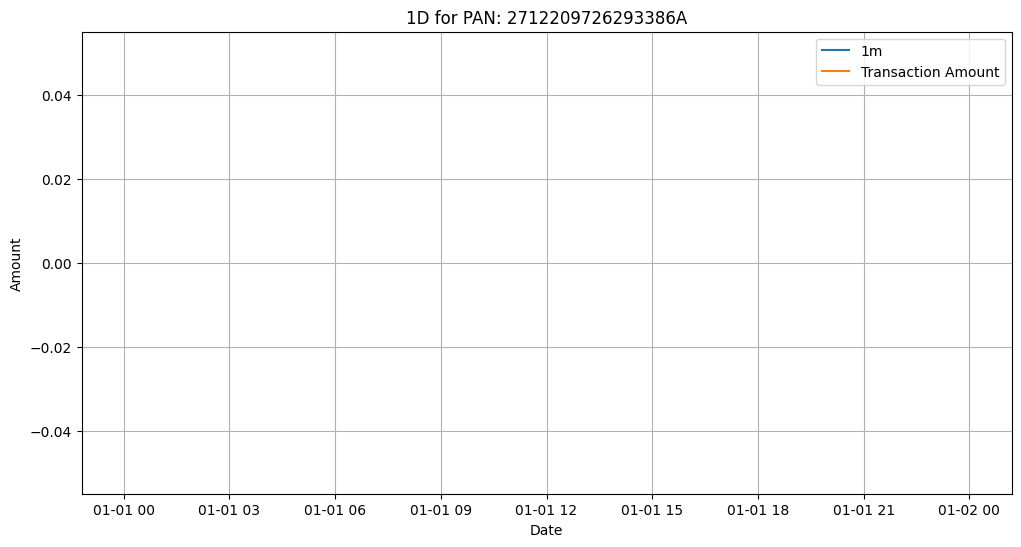

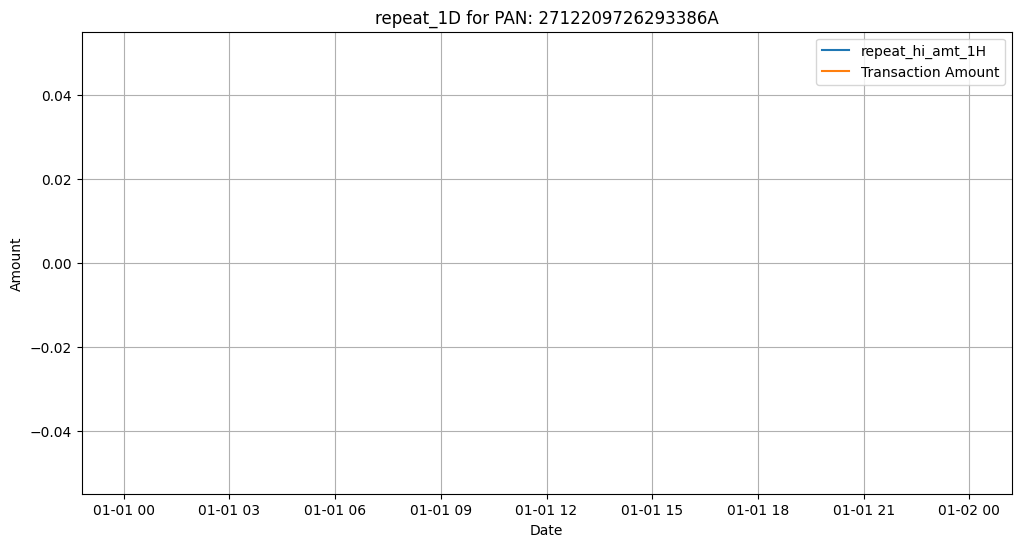

In [15]:
#pan_number = df[df['mdlIsFraudAcct'] == 1]['pan'].unique()[29]  # Select the first pan number for example
pan_number = '2712209726293386A'
subset = df[df['pan'] == pan_number]

# Choose a time range (e.g., first 3 months)
start_date = subset['datetime'].min()
end_date = start_date + pd.DateOffset(months=3)
subset = subset[(subset['datetime'] >= start_date) & (subset['datetime'] <= end_date)]

plt.figure(figsize=(12, 6))
plt.plot(subset['datetime'], subset['1m'], label='1m')
plt.plot(subset['datetime'], subset['transactionAmount'], label='Transaction Amount')

plt.title(f'1D for PAN: {pan_number}')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(subset['datetime'], subset['repeat_hi_amt_1H'], label='repeat_hi_amt_1H')
plt.plot(subset['datetime'], subset['transactionAmount'], label='Transaction Amount')

plt.title(f'repeat_1D for PAN: {pan_number}')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)
plt.show()


## Now that we have a dataframe with some potentially useful features, let's save it to be used in future sessions.

In [16]:
#df[df['is_train'] == 1].to_csv(f'/content/drive/MyDrive/FICO Analytic Challenge/Data/train_features.csv',index=False)
df[df['is_train'] == 0].to_csv(f'/content/drive/MyDrive/FICO Analytic Challenge/Data/test_B_features.csv',index=False)
